In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("ANA-1 Environment Ready. Libraries imported.")

ANA-1 Environment Ready. Libraries imported.


In [3]:
#Pre-processing the main dataset
print("Loading Main MHSDS Performance Data...")

#Loading main dataset
mhsds = pd.read_csv("MHSDS Data_MarPerf_2026_v2.csv", low_memory=False)

mhsds_national = mhsds[mhsds['BREAKDOWN'] == 'England'].copy()

mhsds_national['MEASURE_VALUE'] = pd.to_numeric(mhsds_national['MEASURE_VALUE'], errors='coerce')

print(f"Original dataset rows: {mhsds.shape[0]:,}")
print(f"Filtered National rows: {mhsds_national.shape[0]:,}")
print("Pre-processing complete!")

Loading Main MHSDS Performance Data...
Original dataset rows: 764,377
Filtered National rows: 358
Pre-processing complete!


In [7]:
'''Extracting the following KPI's:
beds, contacts, crisis calls, admissions'''

#Defining target KPIs
kpi_queries = [
    {'name': 'Total Bed Days', 'col': 'MEASURE_ID', 'val': 'MHS24'},
    {'name': 'Total Attended Contacts', 'col': 'MEASURE_ID', 'val': 'MHS30'},
    {'name': 'Crisis Team Contacts', 'col': 'MEASURE_ID', 'val': 'MHS30b'},
    {'name': 'Total Hospital Admissions', 'col': 'MEASURE_NAME', 'val': 'Admissions to hospital in the RP'}
]

kpi_results = []
#Extracting values from dict
for query in kpi_queries:
    row = mhsds_national[mhsds_national[query['col']] == query['val']]
    
    if not row.empty:
        val = row['MEASURE_VALUE'].sum()
        actual_id = row['MEASURE_ID'].iloc[0]
        
        kpi_results.append({
            'KPI': query['name'], 
            'Value': val, 
            'Source': 'MHSDS Data_MarPerf_2026_v2.csv'
        })
        print(f"Extracted {query['name']} (Found under ID: {actual_id}): {val:,.0f}")
    else:
        print(f"Warning: {query['name']} not found.")

print("\nKPIs 1-4 Extracted Successfully.")

Extracted Total Bed Days (Found under ID: MHS24): 700,917
Extracted Total Attended Contacts (Found under ID: MHS30): 2,428,796
Extracted Crisis Team Contacts (Found under ID: MHS30b): 189,763
Extracted Total Hospital Admissions (Found under ID: MHS27): 8,466

KPIs 1-4 Extracted Successfully.


In [11]:
#Extracting KPI RTT
print("Loading RTT Waiting Times Data...")

#Loading RTT dataset
rtt_2a = pd.read_excel("RTT  waiting times.xlsx", sheet_name="Table 2a", skiprows=11)

#Cleaning the column headers
rtt_2a.columns = rtt_2a.columns.astype(str).str.strip().str.replace('\n', '')

#Locating the 'England' row
england_rtt_row = rtt_2a[rtt_2a.iloc[:, 0].str.contains("England", case=False, na=False)]

if not england_rtt_row.empty:
    rtt_percentage = pd.to_numeric(england_rtt_row['Proportion waiting two weeks or less (%)'].values[0], errors='coerce')
    
    kpi_results.append({
        'KPI': 'RTT (Started Treatment within 2 Weeks)', 
        'Value': f"{rtt_percentage}%", 
        'Source': 'RTT waiting times.xlsx (Sheet: Table 2a)'
    })
    print(f"Extracted RTT Performance: {rtt_percentage}%")
else:
    print("Warning: England RTT row not found.")

Loading RTT Waiting Times Data...
Extracted RTT Performance: 72.33069%


In [13]:
#Converting extracted results in a dataframe
df_kpi_final = pd.DataFrame(kpi_results)

#Converting Source mapping table
df_source_mapping = pd.DataFrame({
    "KPI": [
        "Total Bed Days",
        "Total Attended Contacts",
        "Crisis Team Contacts",
        "Total Hospital Admissions",
        "RTT (Started Treatment within 2 Weeks)"
    ],
    "Measure_ID_Reference": [
        "MHS24",
        "MHS30",
        "MHS30b",
        "MHS27", 
        "EIP23j (Table 2a)"
    ],
    "Data_Source": [
        "MHSDS Data_MarPerf_2026_v2.csv",
        "MHSDS Data_MarPerf_2026_v2.csv",
        "MHSDS Data_MarPerf_2026_v2.csv",
        "MHSDS Data_MarPerf_2026_v2.csv",
        "RTT waiting times.xlsx (Sheet: Table 2a)"
    ]
})

print("--- FINAL ANA-1 KPI TABLE ---")
display(df_kpi_final)

print("\n--- ANA-1 SOURCE MAPPING TABLE ---")
display(df_source_mapping)

--- FINAL ANA-1 KPI TABLE ---


,KPI,Value,Source
0,Total Bed Days,700917.0,MHSDS Data_MarPerf_2026_v2.csv
1,Total Attended Contacts,2428796.0,MHSDS Data_MarPerf_2026_v2.csv
2,Crisis Team Contacts,189763.0,MHSDS Data_MarPerf_2026_v2.csv
3,Total Hospital Admissions,8466.0,MHSDS Data_MarPerf_2026_v2.csv
4,RTT (Started Treatment within 2 Weeks),72.33069%,RTT waiting times.xlsx (Sheet: Table 2a)



--- ANA-1 SOURCE MAPPING TABLE ---


,KPI,Measure_ID_Reference,Data_Source
0,Total Bed Days,MHS24,MHSDS Data_MarPerf_2026_v2.csv
1,Total Attended Contacts,MHS30,MHSDS Data_MarPerf_2026_v2.csv
2,Crisis Team Contacts,MHS30b,MHSDS Data_MarPerf_2026_v2.csv
3,Total Hospital Admissions,MHS27,MHSDS Data_MarPerf_2026_v2.csv
4,RTT (Started Treatment within 2 Weeks),EIP23j (Table 2a),RTT waiting times.xlsx (Sheet: Table 2a)


In [14]:
#Export to CSV
df_kpi_final.to_csv("ANA-1_Final_KPI_Table.csv", index=False)
df_source_mapping.to_csv("ANA-1_Source_Mapping.csv", index=False)

print("\nSuccess! Exported 'ANA-1_Final_KPI_Table.csv' & 'ANA-1_Source_Mapping.csv' to your folder.")


Success! Exported 'ANA-1_Final_KPI_Table.csv' & 'ANA-1_Source_Mapping.csv' to your folder.


In [26]:
#Data Visualization
df_volumes = df_kpi_final[df_kpi_final['KPI'] != 'RTT (Started Treatment within 2 Weeks)'].copy()
rtt_row = df_kpi_final[df_kpi_final['KPI'] == 'RTT (Started Treatment within 2 Weeks)'].iloc[0]

rtt_value = float(rtt_row['Value'].replace('%', ''))


Text(0.5, 1.0, 'EIP RTT Pathway Standard (March 2026)')

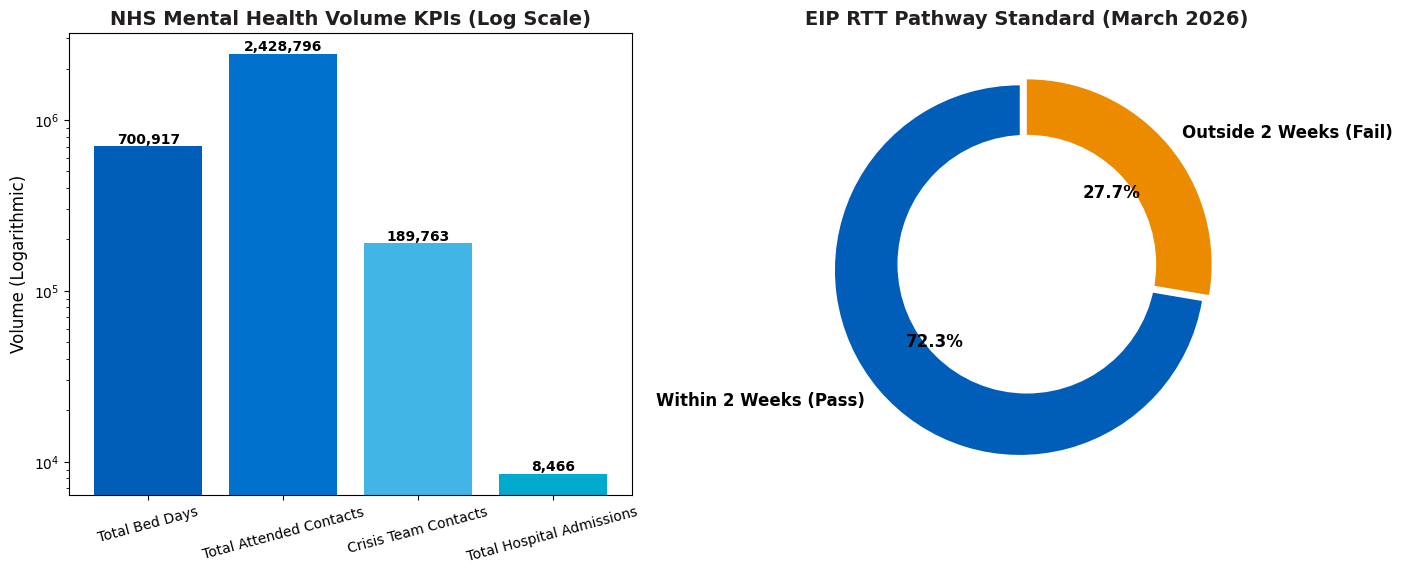

In [27]:
# Bar Chart For KPIs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
nhs_colors = ['#005EB8', '#0072CE', '#41B6E6', '#00A9CE']
bars = ax1.bar(df_volumes['KPI'], df_volumes['Value'], color=nhs_colors)

ax1.set_yscale('log')
ax1.set_title('NHS Mental Health Volume KPIs (Log Scale)', fontsize=14, fontweight='bold', color='#231f20')
ax1.set_ylabel('Volume (Logarithmic)', fontsize=12)
ax1.tick_params(axis='x', rotation=15)

for bar in bars:
    yval = bar.get_height()
    # Format with commas (e.g., 2,400,000) for readability
    ax1.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')


# Donut Chart for RTT Performance
labels = ['Within 2 Weeks (Pass)', 'Outside 2 Weeks (Fail)']
sizes = [rtt_value, 100 - rtt_value]
colors = ['#005EB8', '#ED8B00'] # NHS Blue and Warning Orange
explode = (0.05, 0) # Slightly "pop out" the passing slice

# Draw a standard pie chart first
ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=False, startangle=90, textprops={'fontsize': 12, 'fontweight':'bold'})

# Turn the Pie Chart into a Donut Chart by drawing a white circle in the middle
centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax2.add_patch(centre_circle)
ax2.set_title('EIP RTT Pathway Standard (March 2026)', fontsize=14, fontweight='bold', color='#231f20')